# Response trajectories by `antic_nudge`

This notebook reproduces the response-fraction trajectories for `framing = 1` and `p_anti = 0.5`, with columns split by `antic_nudge`. Fractions are calculated within each `nid` and round, then averaged across `nid`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import pandas as pd

%config InlineBackend.figure_format = 'retina'

DATA_PATH = Path('../Clean_files/07_combined_classified.csv')
RESPONSE_LEVELS = [-1, 0, 1]
BETA_LEVELS = [0.0, 0.5]
ANTIC_NUDGE_LEVELS = [0, 1]
REQUIRED_COLUMNS = [
    'round_no',
    'response',
    'framing',
    'beta',
    'p_anti',
    'nid',
    'antic_nudge',
    'participant_code',
]


In [2]:
df = pd.read_csv(DATA_PATH, sep=',', usecols=REQUIRED_COLUMNS)
plot_data = df.loc[
    (df['framing'] == 1)
    & (df['p_anti'] == 0.5)
    & df['beta'].isin(BETA_LEVELS)
    & df['antic_nudge'].isin(ANTIC_NUDGE_LEVELS)
    & df['response'].isin(RESPONSE_LEVELS),
    REQUIRED_COLUMNS,
].copy()

if sorted(plot_data['antic_nudge'].unique()) != ANTIC_NUDGE_LEVELS:
    raise ValueError('Expected antic_nudge levels 0 and 1 in the filtered data.')

print(f'Rows used: {len(plot_data):,}')
print(f'Rounds: {plot_data.round_no.min()}–{plot_data.round_no.max()}')
display(plot_data.head())

Rows used: 4,200
Rounds: 0–20


,round_no,response,framing,beta,p_anti,nid,antic_nudge,participant_code
0,0,-1.0,1,0.5,0.5,1,0,1orgwsba
1,1,-1.0,1,0.5,0.5,1,0,1orgwsba
2,2,-1.0,1,0.5,0.5,1,0,1orgwsba
3,3,-1.0,1,0.5,0.5,1,0,1orgwsba
4,4,1.0,1,0.5,0.5,1,0,1orgwsba


## Calculate per-network fractions and 95% confidence intervals

In [3]:
group_columns = ['beta', 'antic_nudge', 'nid', 'round_no']
nid_fractions = (
    plot_data.groupby(group_columns)['response']
    .value_counts(normalize=True)
    .unstack('response', fill_value=0)
    .reindex(columns=RESPONSE_LEVELS, fill_value=0)
    .rename_axis(columns='response')
    .stack(future_stack=True)
    .rename('fraction')
    .reset_index()
)

mean_fractions = (
    nid_fractions.groupby(
        ['beta', 'antic_nudge', 'round_no', 'response'], as_index=False
    ).agg(
        mean_fraction=('fraction', 'mean'),
        sem_fraction=('fraction', 'sem'),
        n_nid=('nid', 'nunique'),
    )
)
mean_fractions['ci95'] = 1.96 * mean_fractions['sem_fraction']
mean_fractions['ci_lower'] = (mean_fractions['mean_fraction'] - mean_fractions['ci95']).clip(lower=0)
mean_fractions['ci_upper'] = (mean_fractions['mean_fraction'] + mean_fractions['ci95']).clip(upper=1)

fraction_sums = mean_fractions.groupby(
    ['beta', 'antic_nudge', 'round_no']
)['mean_fraction'].sum()
assert fraction_sums.sub(1).abs().max() < 1e-12
display(mean_fractions.head(9))

,beta,antic_nudge,round_no,response,mean_fraction,sem_fraction,n_nid,ci95,ci_lower,ci_upper
0,0.0,0,0,-1,0.500000,0.000000,15,0.000000,0.500000,0.500000
1,0.0,0,0,0,0.000000,0.000000,15,0.000000,0.000000,0.000000
2,0.0,0,0,1,0.500000,0.000000,15,0.000000,0.500000,0.500000
3,0.0,0,1,-1,0.483333,0.016667,15,0.032667,0.450667,0.516000
4,0.0,0,1,0,0.016667,0.016667,15,0.032667,0.000000,0.049333
5,0.0,0,1,1,0.500000,0.000000,15,0.000000,0.500000,0.500000
6,0.0,0,2,-1,0.416667,0.039841,15,0.078088,0.338578,0.494755
7,0.0,0,2,0,0.100000,0.047559,15,0.093217,0.006783,0.193217
8,0.0,0,2,1,0.483333,0.045426,15,0.089034,0.394299,0.572368


## Plot the 2 × 2 trajectories

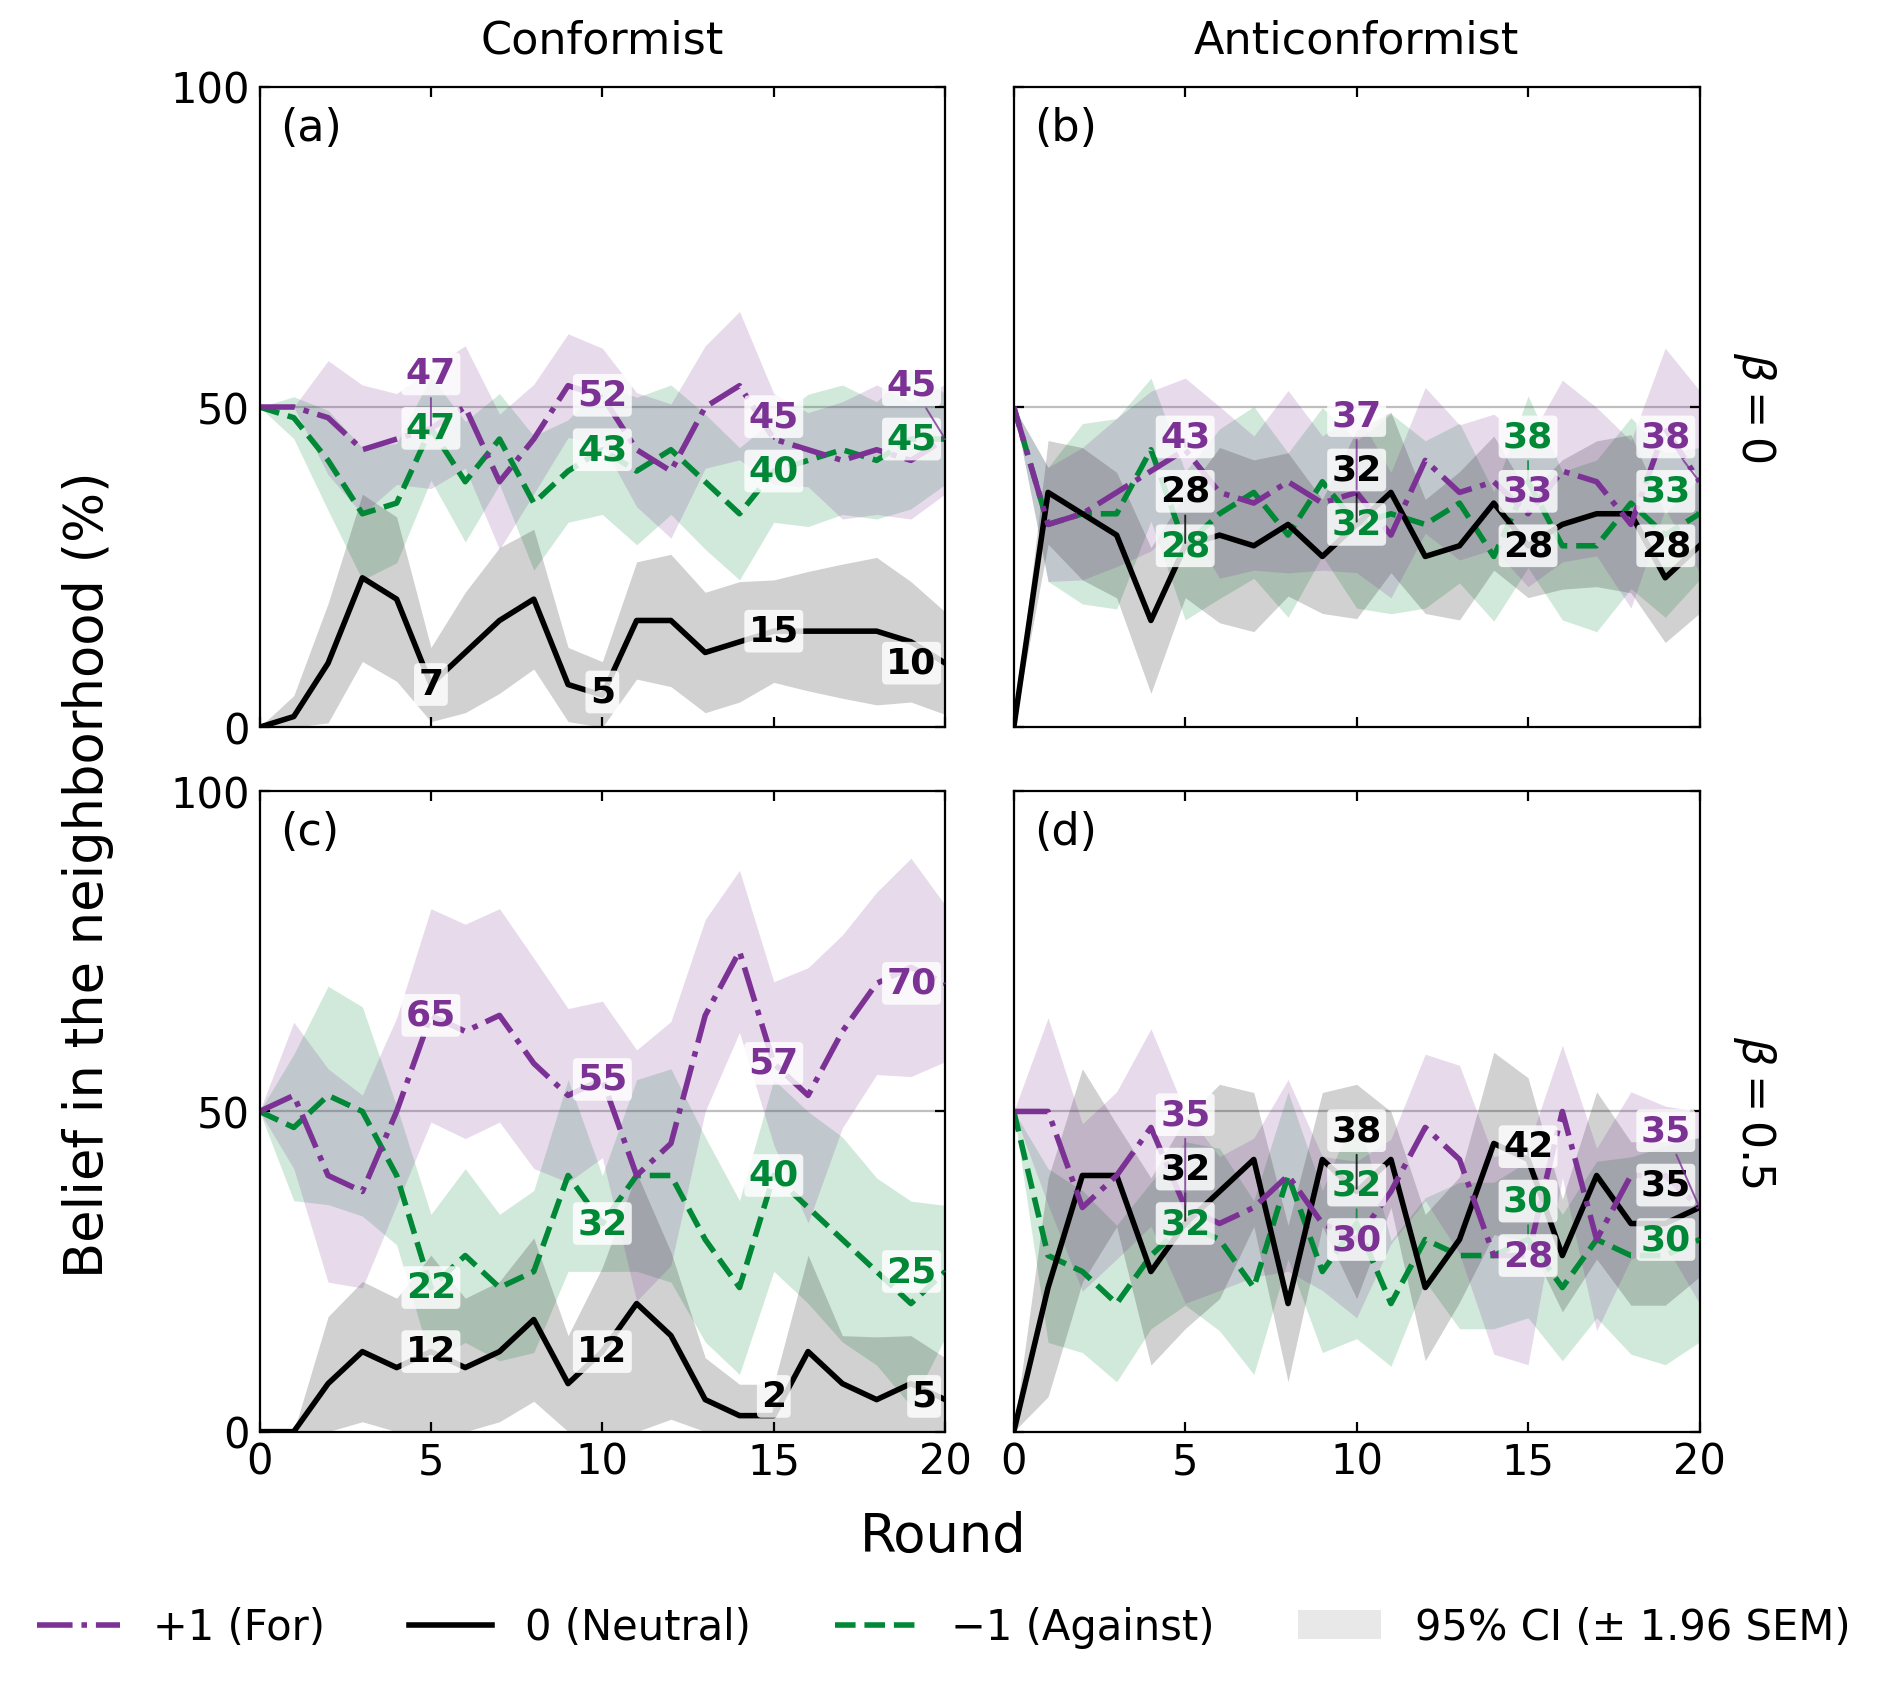

In [4]:
colors = {-1: '#008837', 0: '#000000', 1: '#7b3294'} # colors from colorbrewer2.org
labels = {-1: '−1 (Against)', 0: '0 (Neutral)', 1: '+1 (For)'}
annotation_rounds = [5, 10, 15, 20]
line_styles = {-1: '--', 0: '-', 1: '-.'}

def spread_annotation_positions(values, min_gap=0.085, lower=0.055, upper=0.945):
    ordered = sorted(values, key=values.get)
    positions = {response: max(lower, min(upper, values[response])) for response in ordered}
    for previous, current in zip(ordered, ordered[1:]):
        positions[current] = max(positions[current], positions[previous] + min_gap)
    overflow = positions[ordered[-1]] - upper
    if overflow > 0:
        positions = {response: position - overflow for response, position in positions.items()}
    underflow = lower - positions[ordered[0]]
    if underflow > 0:
        positions = {response: position + underflow for response, position in positions.items()}
    return positions

plt.rcParams.update({
    'font.size': 15,
    'axes.labelsize': 19,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 15,
})
fig, axes = plt.subplots(2, 2, figsize=(9, 8.2), sharex=True, sharey=True)

for row, beta in enumerate(BETA_LEVELS):
    for col, antic_nudge in enumerate(ANTIC_NUDGE_LEVELS):
        ax = axes[row, col]
        panel = mean_fractions.loc[
            (mean_fractions['beta'] == beta)
            & (mean_fractions['antic_nudge'] == antic_nudge)
        ]

        trajectories = {}
        for response in RESPONSE_LEVELS:
            trajectory = panel.loc[panel['response'] == response].sort_values('round_no')
            trajectories[response] = trajectory
            ax.fill_between(
                trajectory['round_no'], trajectory['ci_lower'], trajectory['ci_upper'],
                color=colors[response], alpha=0.18, linewidth=0,
            )
            ax.plot(
                trajectory['round_no'], trajectory['mean_fraction'],
                color=colors[response], linewidth=2,
                linestyle=line_styles[response],
            )

        for annotation_round in annotation_rounds:
            values = {
                response: trajectories[response].loc[
                    trajectories[response]['round_no'] == annotation_round, 'mean_fraction'
                ].iloc[0]
                for response in RESPONSE_LEVELS
            }
            label_positions = spread_annotation_positions(values)
            text_x = annotation_round - 0.25 if annotation_round == 20 else annotation_round
            horizontal_alignment = 'right' if annotation_round == 20 else 'center'
            for response in RESPONSE_LEVELS:
                ax.annotate(
                    f'{values[response] * 100:.0f}',
                    xy=(annotation_round, values[response]),
                    xytext=(text_x, label_positions[response]), textcoords='data',
                    color=colors[response], fontsize=13, fontweight='bold',
                    ha=horizontal_alignment, va='center', clip_on=True, zorder=5,
                    bbox=dict(boxstyle='round,pad=0.12', facecolor='white', edgecolor='none', alpha=0.82),
                    arrowprops=dict(arrowstyle='-', color=colors[response], linewidth=0.7, alpha=0.8, shrinkA=1, shrinkB=1),
                )

        if row == 0:
            nudge_label = 'Conformist' if antic_nudge == 0 else 'Anticonformist'
            ax.set_title(nudge_label, fontsize=16, pad=12)
        panel_label = chr(ord('a') + row * len(ANTIC_NUDGE_LEVELS) + col)
        ax.text(
            0.03, 0.97, f'({panel_label})',
            transform=ax.transAxes, ha='left', va='top',
            fontsize=16, fontweight='normal',
        )
        ax.set_xlim(plot_data['round_no'].min(), plot_data['round_no'].max())
        ax.set_ylim(0, 1)
        ax.set_yticks([0, 0.5, 1], ['0', '50', '100'])
        ax.set_xticks(range(int(plot_data['round_no'].min()), int(plot_data['round_no'].max()) + 1, 5))
        ax.grid(False)
        ax.axhline(0.5, color='0.75', linewidth=0.8, linestyle='-', zorder=0)
        ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
        for spine in ax.spines.values():
            spine.set_visible(True)
        if col == len(ANTIC_NUDGE_LEVELS) - 1:
            ax.text(
                1.08, 0.5, rf'$\beta = {beta:g}$', transform=ax.transAxes,
                rotation=270, va='center', ha='center', fontsize=16,
            )

legend_order = [1, 0, -1]
legend_handles = [
    Line2D(
        [0], [0], color=colors[response], linewidth=2,
        linestyle=line_styles[response], label=labels[response],
    )
    for response in legend_order
]
legend_handles.append(Patch(facecolor='0.5', alpha=0.18, edgecolor='none', label='95% CI (± 1.96 SEM)'))
fig.legend(handles=legend_handles, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.005))
fig.supxlabel('Round', fontsize=19, y=0.08)
fig.supylabel('Belief in the neighborhood (%)', fontsize=19, x=0.01)
fig.subplots_adjust(left=0.12, right=0.92, bottom=0.16, top=0.98, wspace=0.10, hspace=0.10)
# fig.savefig('Figure_3a.png', dpi=300, bbox_inches='tight')
plt.show()

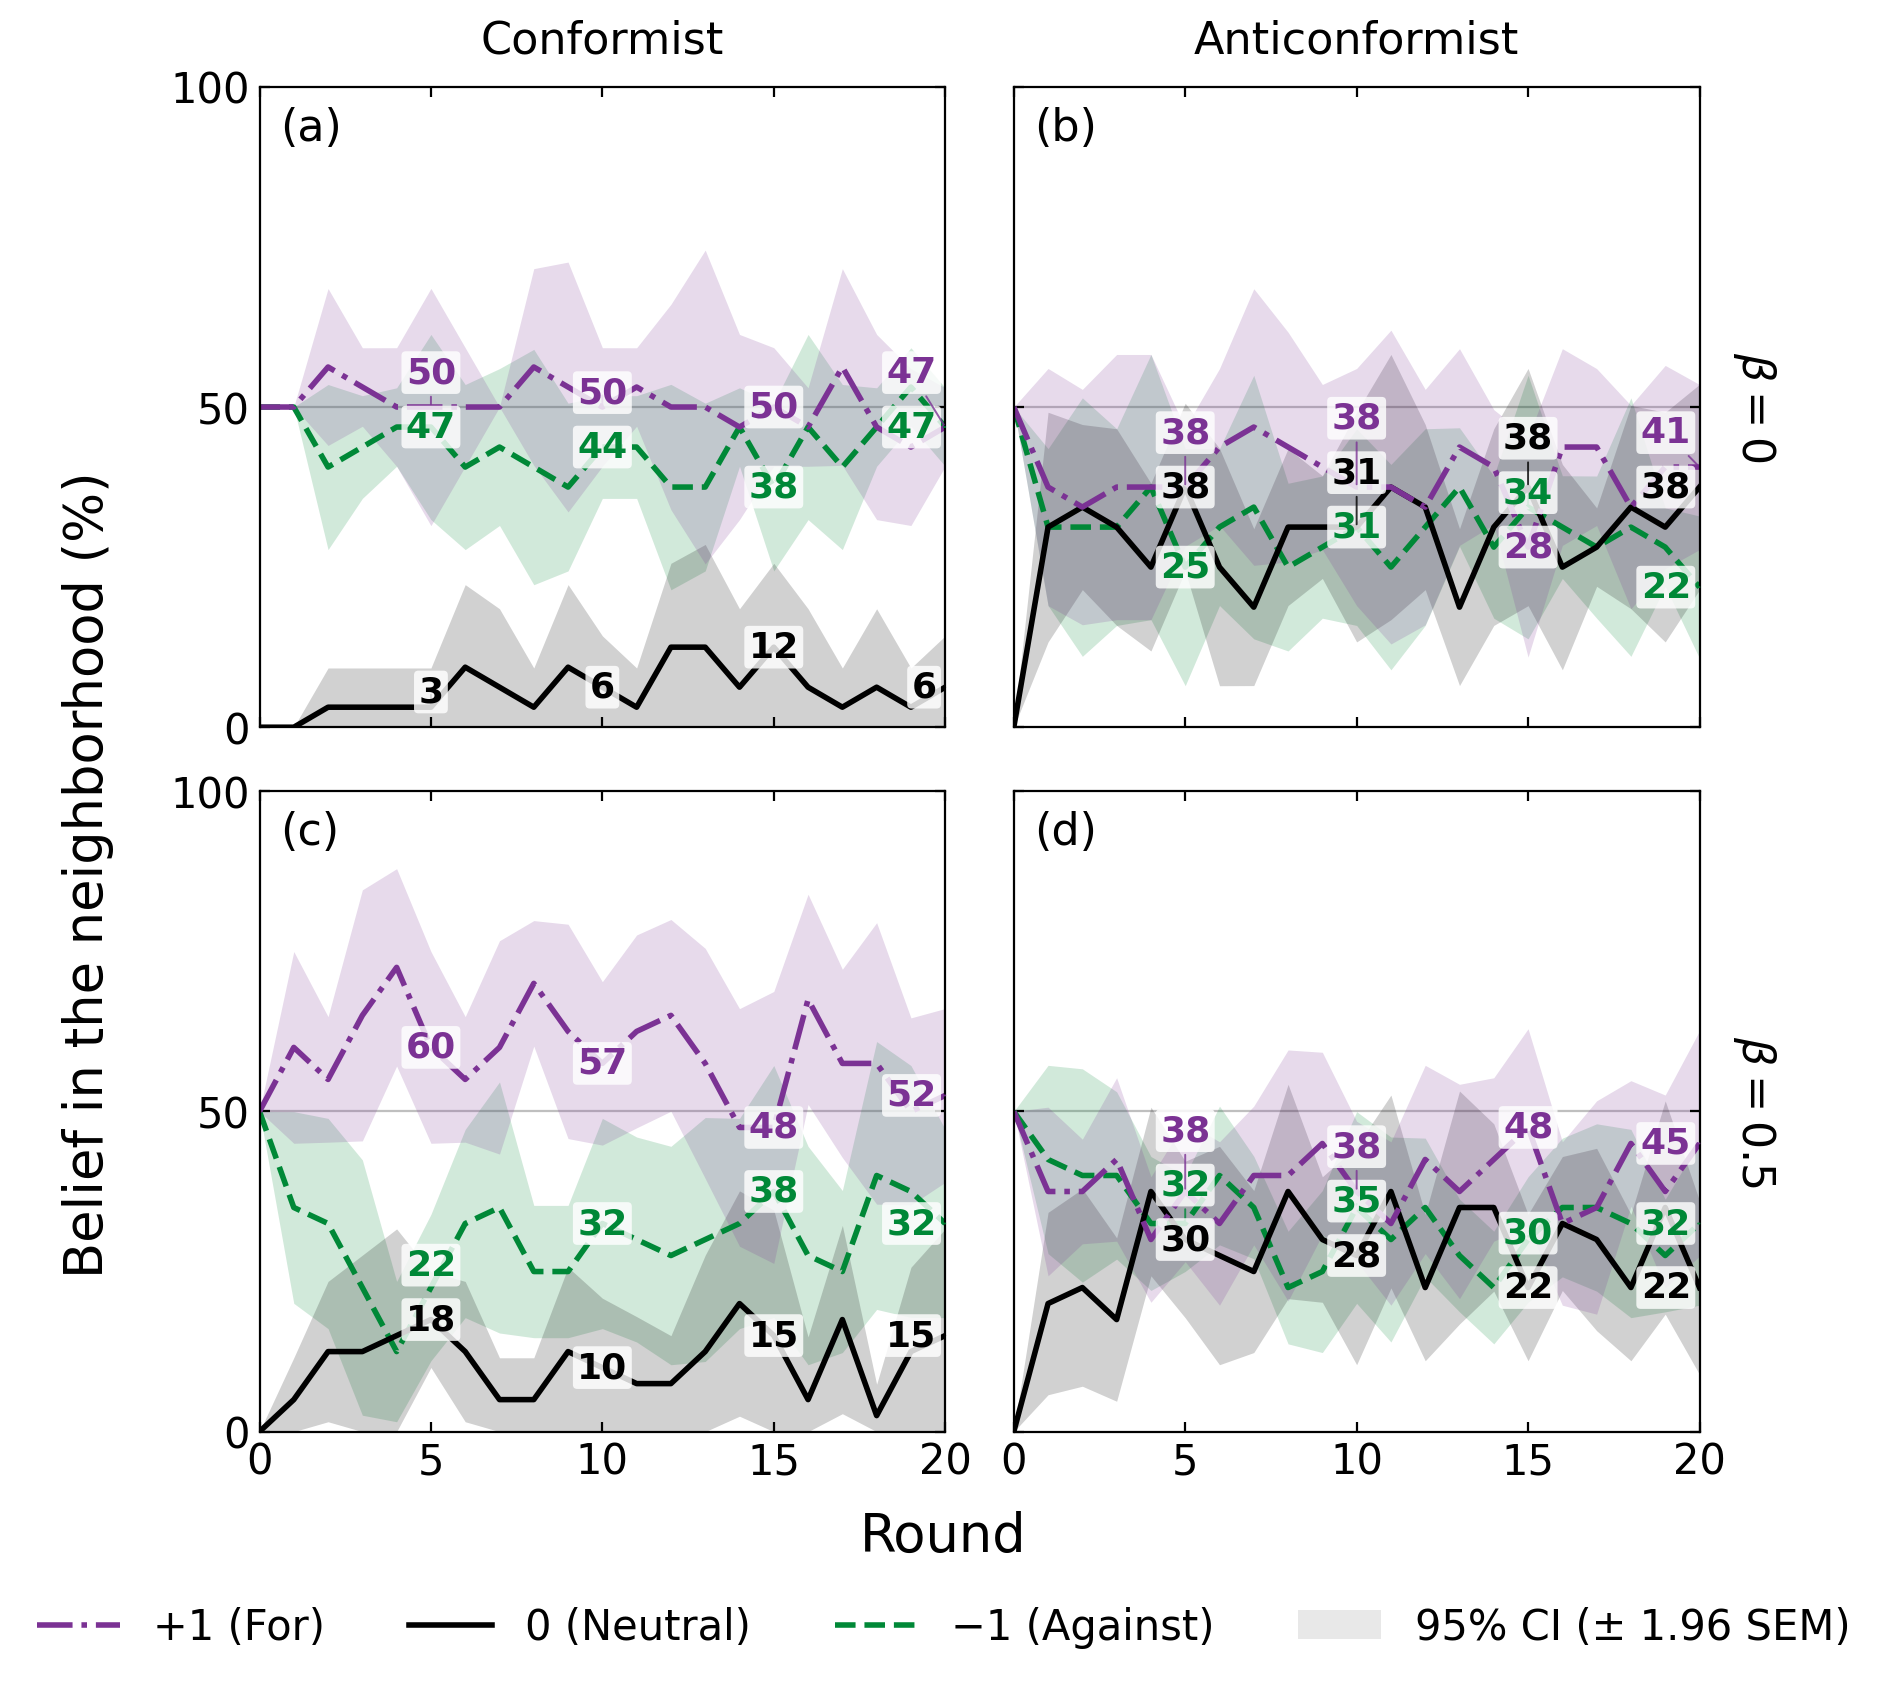

In [5]:
# Repeat the same analysis and figure for framing = 2
plot_data_framing_2 = df.loc[
    (df['framing'] == 2)
    & (df['p_anti'] == 0.5)
    & df['beta'].isin(BETA_LEVELS)
    & df['antic_nudge'].isin(ANTIC_NUDGE_LEVELS)
    & df['response'].isin(RESPONSE_LEVELS),
    REQUIRED_COLUMNS,
].copy()

nid_fractions_framing_2 = (
    plot_data_framing_2.groupby(group_columns)['response']
    .value_counts(normalize=True)
    .unstack('response', fill_value=0)
    .reindex(columns=RESPONSE_LEVELS, fill_value=0)
    .rename_axis(columns='response')
    .stack(future_stack=True)
    .rename('fraction')
    .reset_index()
)

mean_fractions_framing_2 = (
    nid_fractions_framing_2.groupby(
        ['beta', 'antic_nudge', 'round_no', 'response'], as_index=False
    ).agg(
        mean_fraction=('fraction', 'mean'),
        sem_fraction=('fraction', 'sem'),
        n_nid=('nid', 'nunique'),
    )
)
mean_fractions_framing_2['ci95'] = 1.96 * mean_fractions_framing_2['sem_fraction']
mean_fractions_framing_2['ci_lower'] = (
    mean_fractions_framing_2['mean_fraction'] - mean_fractions_framing_2['ci95']
).clip(lower=0)
mean_fractions_framing_2['ci_upper'] = (
    mean_fractions_framing_2['mean_fraction'] + mean_fractions_framing_2['ci95']
).clip(upper=1)
fraction_sums_framing_2 = mean_fractions_framing_2.groupby(
    ['beta', 'antic_nudge', 'round_no']
)['mean_fraction'].sum()
assert fraction_sums_framing_2.sub(1).abs().max() < 1e-12

fig, axes = plt.subplots(2, 2, figsize=(9, 8.2), sharex=True, sharey=True)
for row, beta in enumerate(BETA_LEVELS):
    for col, antic_nudge in enumerate(ANTIC_NUDGE_LEVELS):
        ax = axes[row, col]
        panel = mean_fractions_framing_2.loc[
            (mean_fractions_framing_2['beta'] == beta)
            & (mean_fractions_framing_2['antic_nudge'] == antic_nudge)
        ]
        trajectories = {}
        for response in RESPONSE_LEVELS:
            trajectory = panel.loc[panel['response'] == response].sort_values('round_no')
            trajectories[response] = trajectory
            ax.fill_between(
                trajectory['round_no'], trajectory['ci_lower'], trajectory['ci_upper'],
                color=colors[response], alpha=0.18, linewidth=0,
            )
            ax.plot(
                trajectory['round_no'], trajectory['mean_fraction'],
                color=colors[response], linewidth=2,
                linestyle=line_styles[response],
            )

        for annotation_round in annotation_rounds:
            values = {
                response: trajectories[response].loc[
                    trajectories[response]['round_no'] == annotation_round, 'mean_fraction'
                ].iloc[0]
                for response in RESPONSE_LEVELS
            }
            label_positions = spread_annotation_positions(values)
            text_x = annotation_round - 0.25 if annotation_round == 20 else annotation_round
            horizontal_alignment = 'right' if annotation_round == 20 else 'center'
            for response in RESPONSE_LEVELS:
                ax.annotate(
                    f'{values[response] * 100:.0f}', xy=(annotation_round, values[response]),
                    xytext=(text_x, label_positions[response]), textcoords='data',
                    color=colors[response], fontsize=13, fontweight='bold',
                    ha=horizontal_alignment, va='center', clip_on=True, zorder=5,
                    bbox=dict(boxstyle='round,pad=0.12', facecolor='white', edgecolor='none', alpha=0.82),
                    arrowprops=dict(arrowstyle='-', color=colors[response], linewidth=0.7, alpha=0.8, shrinkA=1, shrinkB=1),
                )

        if row == 0:
            nudge_label = 'Conformist' if antic_nudge == 0 else 'Anticonformist'
            ax.set_title(nudge_label, fontsize=16, pad=12)
        panel_label = chr(ord('a') + row * len(ANTIC_NUDGE_LEVELS) + col)
        ax.text(
            0.03, 0.97, f'({panel_label})',
            transform=ax.transAxes, ha='left', va='top',
            fontsize=16, fontweight='normal',
        )
        ax.set_xlim(plot_data_framing_2['round_no'].min(), plot_data_framing_2['round_no'].max())
        ax.set_ylim(0, 1)
        ax.set_yticks([0, 0.5, 1], ['0', '50', '100'])
        ax.set_xticks(range(int(plot_data_framing_2['round_no'].min()), int(plot_data_framing_2['round_no'].max()) + 1, 5))
        ax.grid(False)
        ax.axhline(0.5, color='0.75', linewidth=0.8, linestyle='-', zorder=0)
        ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
        for spine in ax.spines.values():
            spine.set_visible(True)
        if col == len(ANTIC_NUDGE_LEVELS) - 1:
            ax.text(1.08, 0.5, rf'$\beta = {beta:g}$', transform=ax.transAxes, rotation=270, va='center', ha='center', fontsize=16)

legend_handles = [
    Line2D(
        [0], [0], color=colors[response], linewidth=2,
        linestyle=line_styles[response], label=labels[response],
    )
    for response in legend_order
]
legend_handles.append(Patch(facecolor='0.5', alpha=0.18, edgecolor='none', label='95% CI (± 1.96 SEM)'))
fig.legend(handles=legend_handles, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.005))
fig.supxlabel('Round', fontsize=19, y=0.08)
fig.supylabel('Belief in the neighborhood (%)', fontsize=19, x=0.01)
fig.subplots_adjust(left=0.12, right=0.92, bottom=0.16, top=0.98, wspace=0.10, hspace=0.10)
# fig.savefig('Figure_3b.png', dpi=300, bbox_inches='tight')
plt.show()

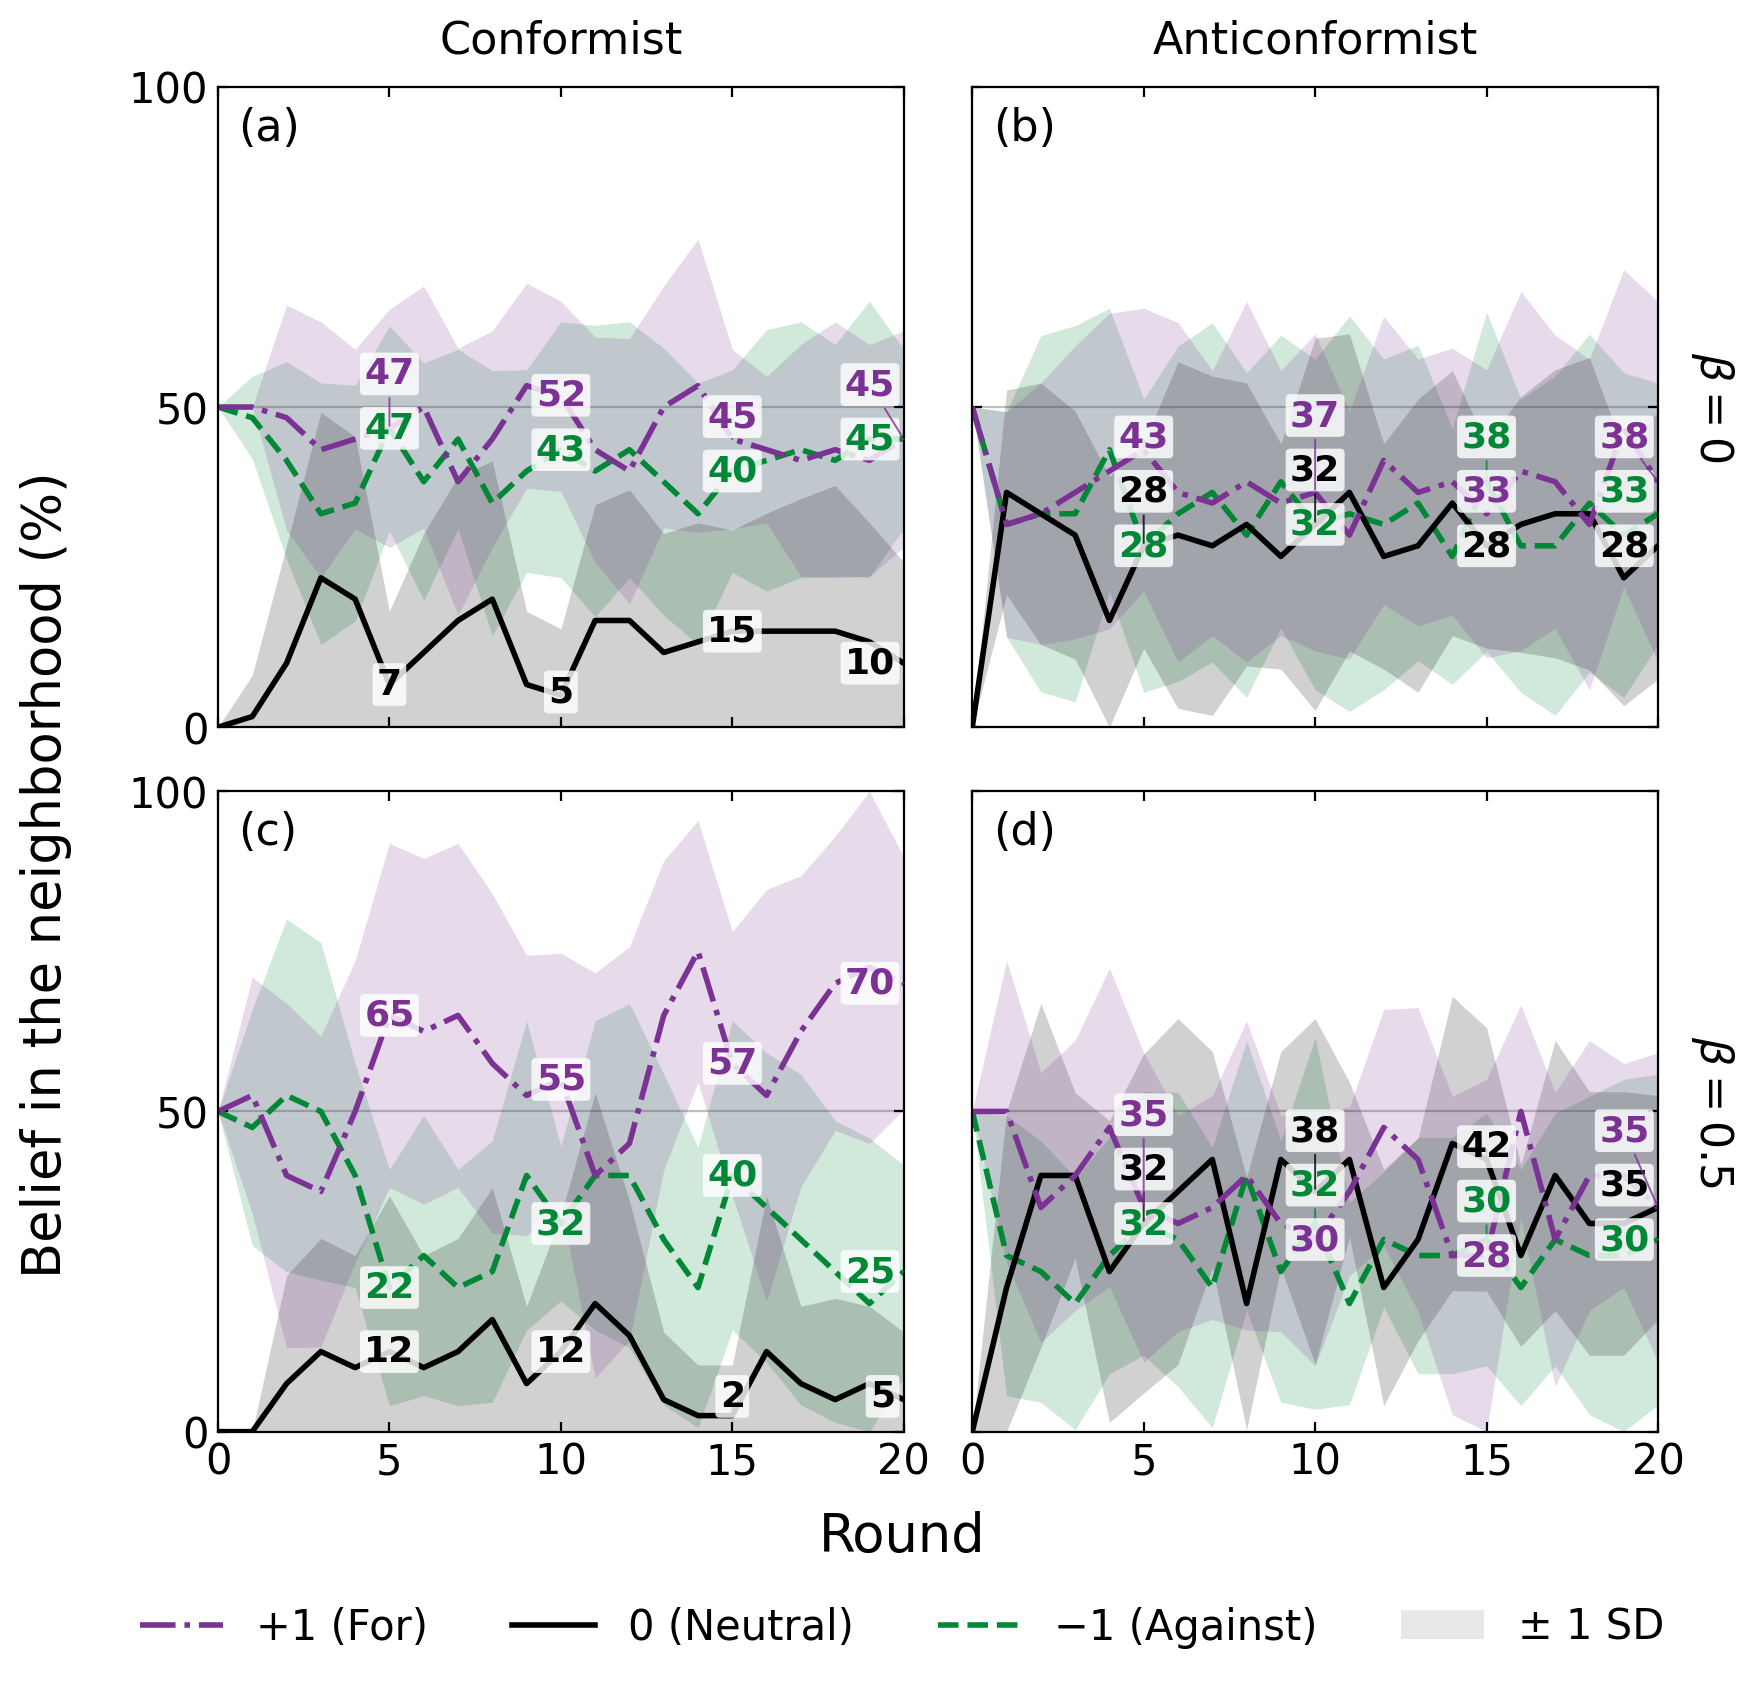

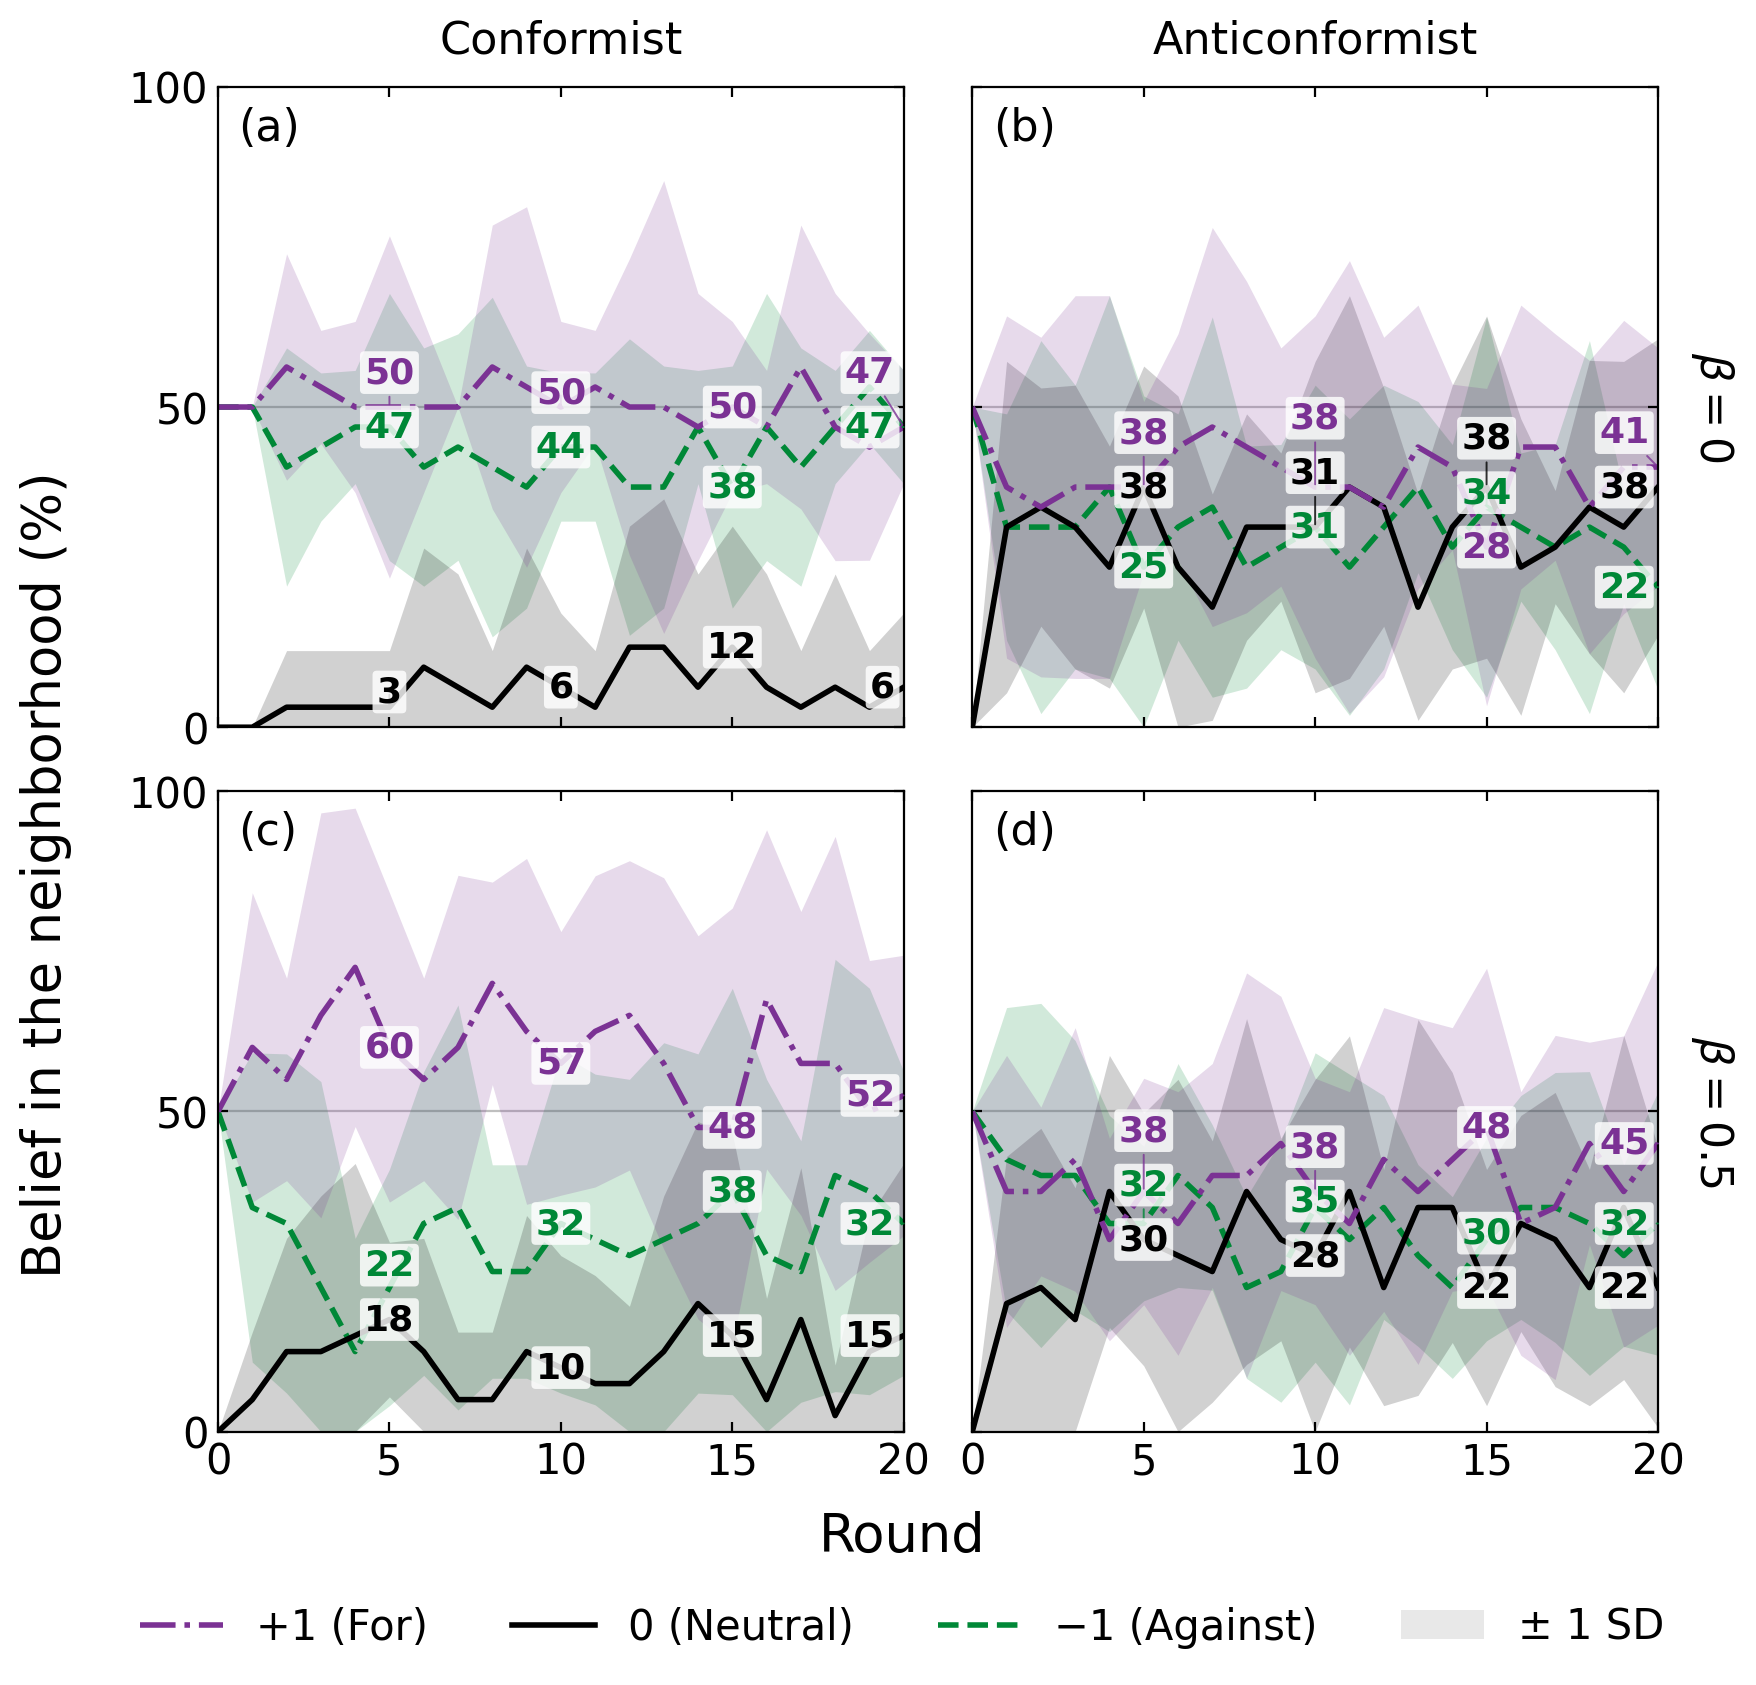

In [6]:
# Create the same trajectories with mean ± 1 SD bands.
def make_nudge_sd_summary(nid_table, group_columns):
    summary = (
        nid_table.groupby(group_columns, as_index=False)
        .agg(
            mean_fraction=('fraction', 'mean'),
            sd_fraction=('fraction', 'std'),
            n_nid=('nid', 'nunique'),
        )
    )
    summary['sd_fraction'] = summary['sd_fraction'].fillna(0)
    summary['sd_lower'] = (
        summary['mean_fraction'] - summary['sd_fraction']
    ).clip(lower=0)
    summary['sd_upper'] = (
        summary['mean_fraction'] + summary['sd_fraction']
    ).clip(upper=1)
    return summary

mean_fractions_sd = make_nudge_sd_summary(
    nid_fractions, ['beta', 'antic_nudge', 'round_no', 'response']
)
mean_fractions_framing_2_sd = make_nudge_sd_summary(
    nid_fractions_framing_2,
    ['beta', 'antic_nudge', 'round_no', 'response'],
)

def plot_nudge_trajectories_sd(summary, x_data, output_name):
    fig, axes = plt.subplots(2, 2, figsize=(9, 8.2), sharex=True, sharey=True)

    for row, beta in enumerate(BETA_LEVELS):
        for col, antic_nudge in enumerate(ANTIC_NUDGE_LEVELS):
            ax = axes[row, col]
            panel = summary.loc[
                (summary['beta'] == beta)
                & (summary['antic_nudge'] == antic_nudge)
            ]
            trajectories = {}
            for response in RESPONSE_LEVELS:
                trajectory = panel.loc[
                    panel['response'] == response
                ].sort_values('round_no')
                trajectories[response] = trajectory
                ax.fill_between(
                    trajectory['round_no'], trajectory['sd_lower'],
                    trajectory['sd_upper'], color=colors[response],
                    alpha=0.18, linewidth=0,
                )
                ax.plot(
                    trajectory['round_no'], trajectory['mean_fraction'],
                    color=colors[response], linewidth=2,
                    linestyle=line_styles[response],
                )

            for annotation_round in annotation_rounds:
                values = {
                    response: trajectories[response].loc[
                        trajectories[response]['round_no'] == annotation_round,
                        'mean_fraction',
                    ].iloc[0]
                    for response in RESPONSE_LEVELS
                }
                label_positions = spread_annotation_positions(values)
                text_x = (
                    annotation_round - 0.25
                    if annotation_round == 20
                    else annotation_round
                )
                ha = 'right' if annotation_round == 20 else 'center'
                for response in RESPONSE_LEVELS:
                    ax.annotate(
                        f'{values[response] * 100:.0f}',
                        xy=(annotation_round, values[response]),
                        xytext=(text_x, label_positions[response]),
                        textcoords='data', color=colors[response],
                        fontsize=13, fontweight='bold', ha=ha, va='center',
                        clip_on=True, zorder=5,
                        bbox=dict(
                            boxstyle='round,pad=0.12', facecolor='white',
                            edgecolor='none', alpha=0.82,
                        ),
                        arrowprops=dict(
                            arrowstyle='-', color=colors[response],
                            linewidth=0.7, alpha=0.8, shrinkA=1, shrinkB=1,
                        ),
                    )

            if row == 0:
                nudge_label = (
                    'Conformist' if antic_nudge == 0 else 'Anticonformist'
                )
                ax.set_title(nudge_label, fontsize=16, pad=12)
            panel_label = chr(ord('a') + row * len(ANTIC_NUDGE_LEVELS) + col)
            ax.text(
                0.03, 0.97, f'({panel_label})', transform=ax.transAxes,
                ha='left', va='top', fontsize=16, fontweight='normal',
            )
            ax.set_xlim(x_data['round_no'].min(), x_data['round_no'].max())
            ax.set_ylim(0, 1)
            ax.set_yticks([0, 0.5, 1], ['0', '50', '100'])
            ax.set_xticks(
                range(
                    int(x_data['round_no'].min()),
                    int(x_data['round_no'].max()) + 1, 5,
                )
            )
            ax.grid(False)
            ax.axhline(0.5, color='0.75', linewidth=0.8, linestyle='-', zorder=0)
            ax.tick_params(
                axis='both', which='both', direction='in', top=True, right=True
            )
            for spine in ax.spines.values():
                spine.set_visible(True)
            if col == len(ANTIC_NUDGE_LEVELS) - 1:
                ax.text(
                    1.08, 0.5, rf'$\beta = {beta:g}$',
                    transform=ax.transAxes, rotation=270,
                    va='center', ha='center', fontsize=16,
                )

    legend_handles = [
        Line2D(
            [0], [0], color=colors[response], linewidth=2,
            linestyle=line_styles[response], label=labels[response],
        )
        for response in legend_order
    ]
    legend_handles.append(
        Patch(facecolor='0.5', alpha=0.18, edgecolor='none', label='± 1 SD')
    )
    fig.legend(
        handles=legend_handles, loc='lower center', ncol=4, frameon=False,
        bbox_to_anchor=(0.5, 0.005),
    )
    fig.supxlabel('Round', fontsize=19, y=0.08)
    fig.supylabel('Belief in the neighborhood (%)', fontsize=19, x=0.01)
    fig.subplots_adjust(
        left=0.12, right=0.92, bottom=0.16, top=0.98,
        wspace=0.10, hspace=0.10,
    )
    # fig.savefig(output_name, dpi=300, bbox_inches='tight')
    plt.show()

plot_nudge_trajectories_sd(
    mean_fractions_sd, plot_data, 'Figure_3a_sd.png'
)
plot_nudge_trajectories_sd(
    mean_fractions_framing_2_sd, plot_data_framing_2, 'Figure_3b_sd.png'
)

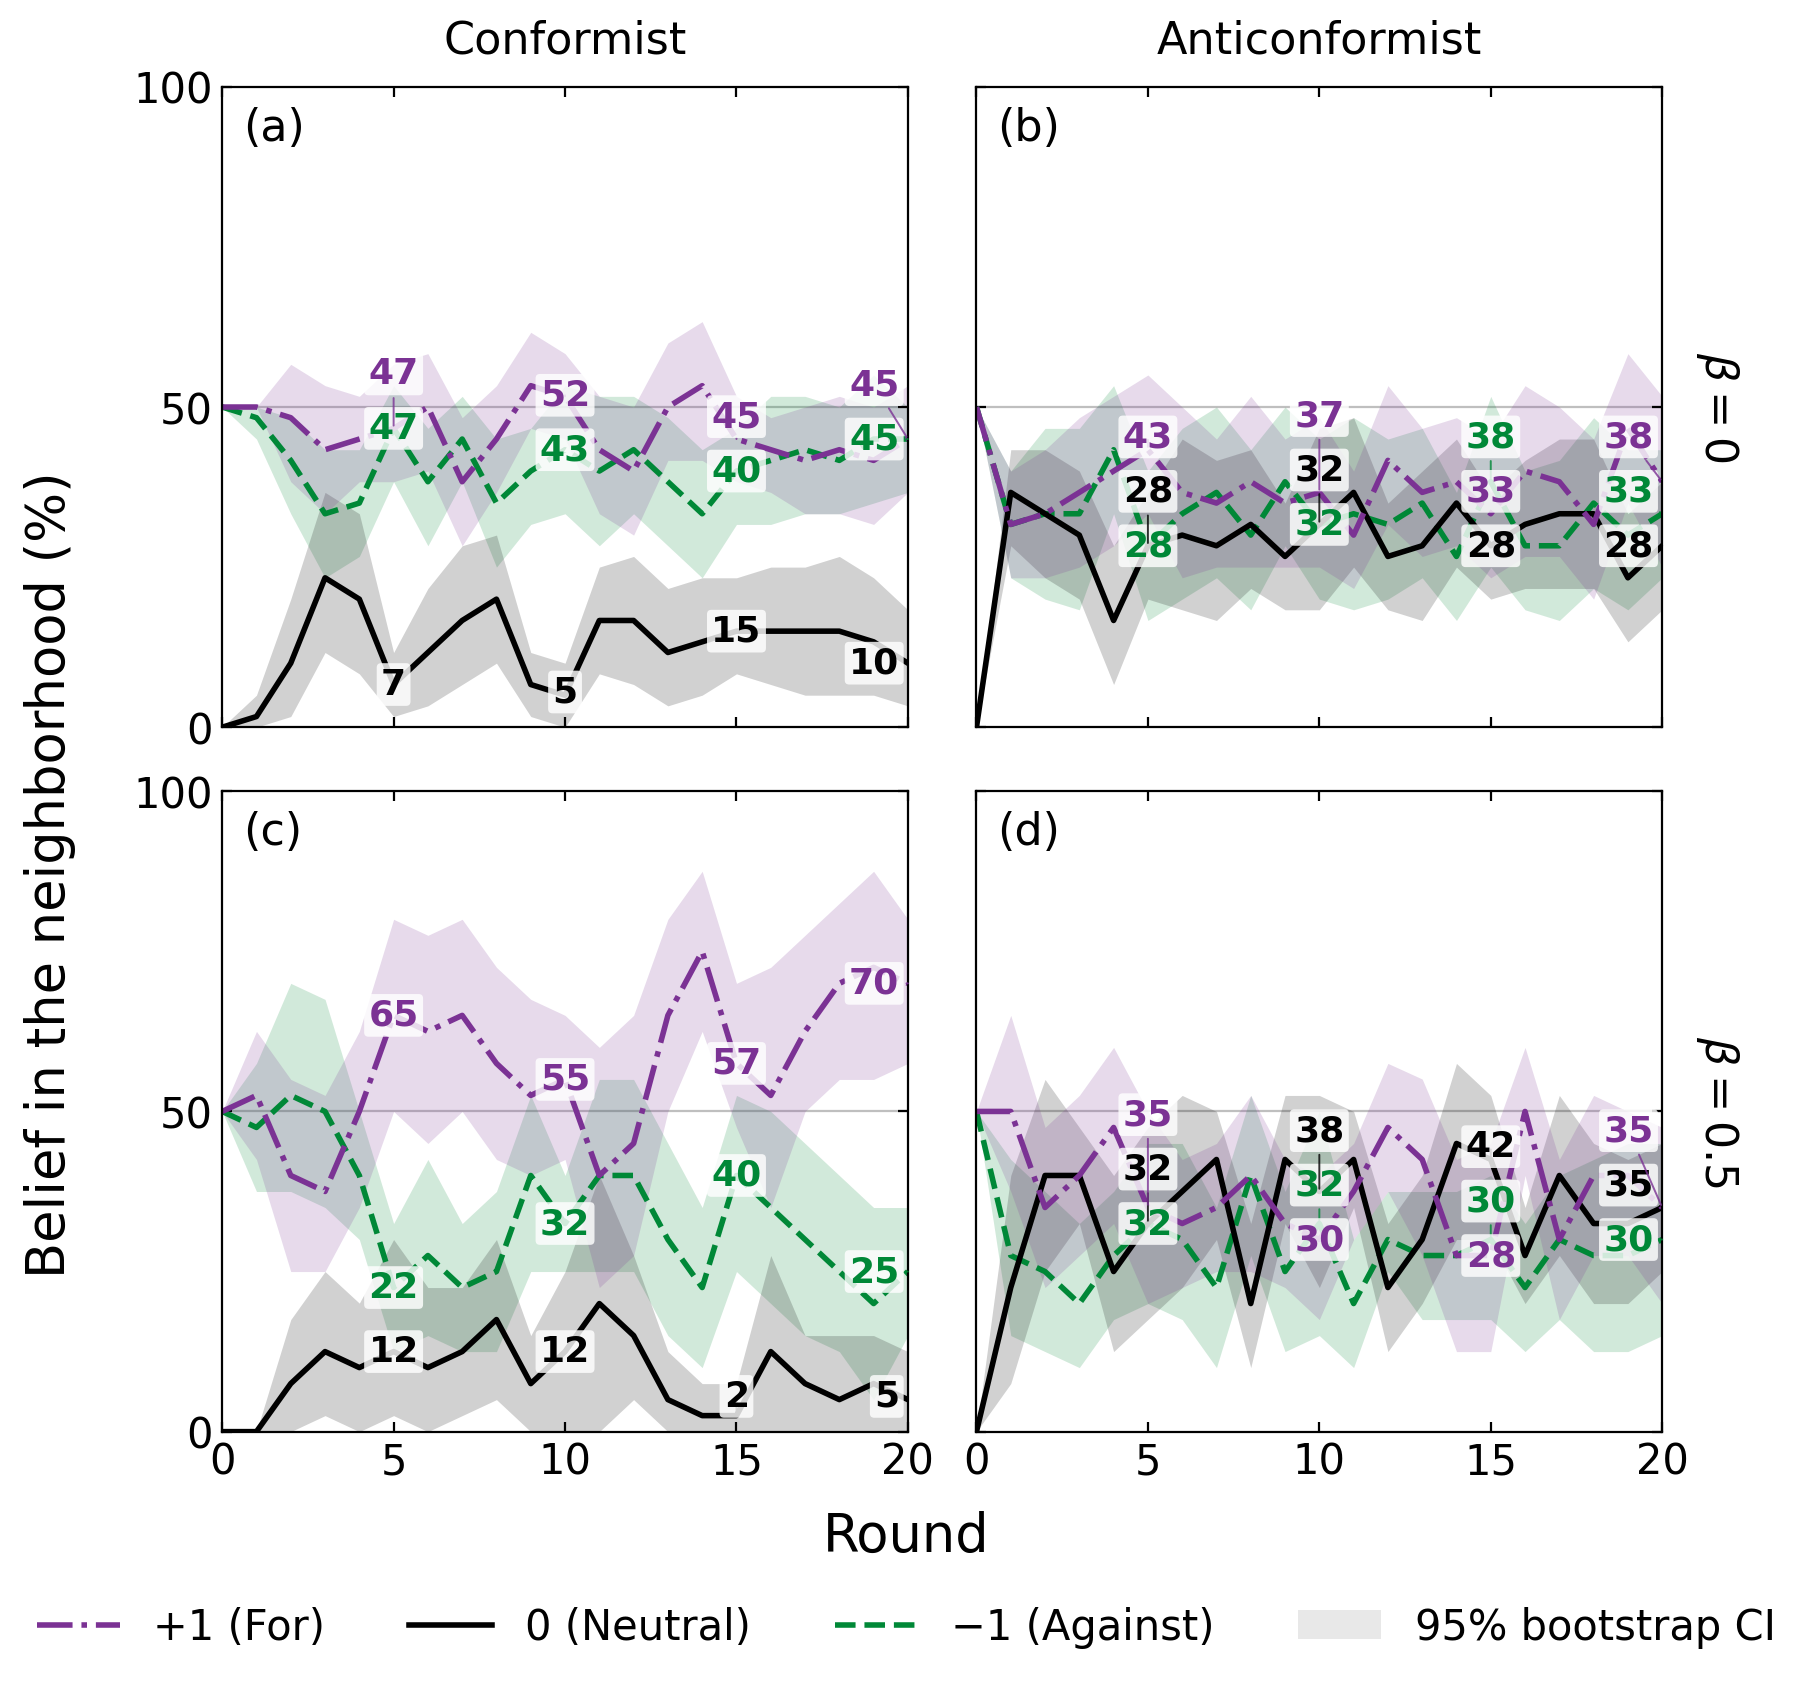

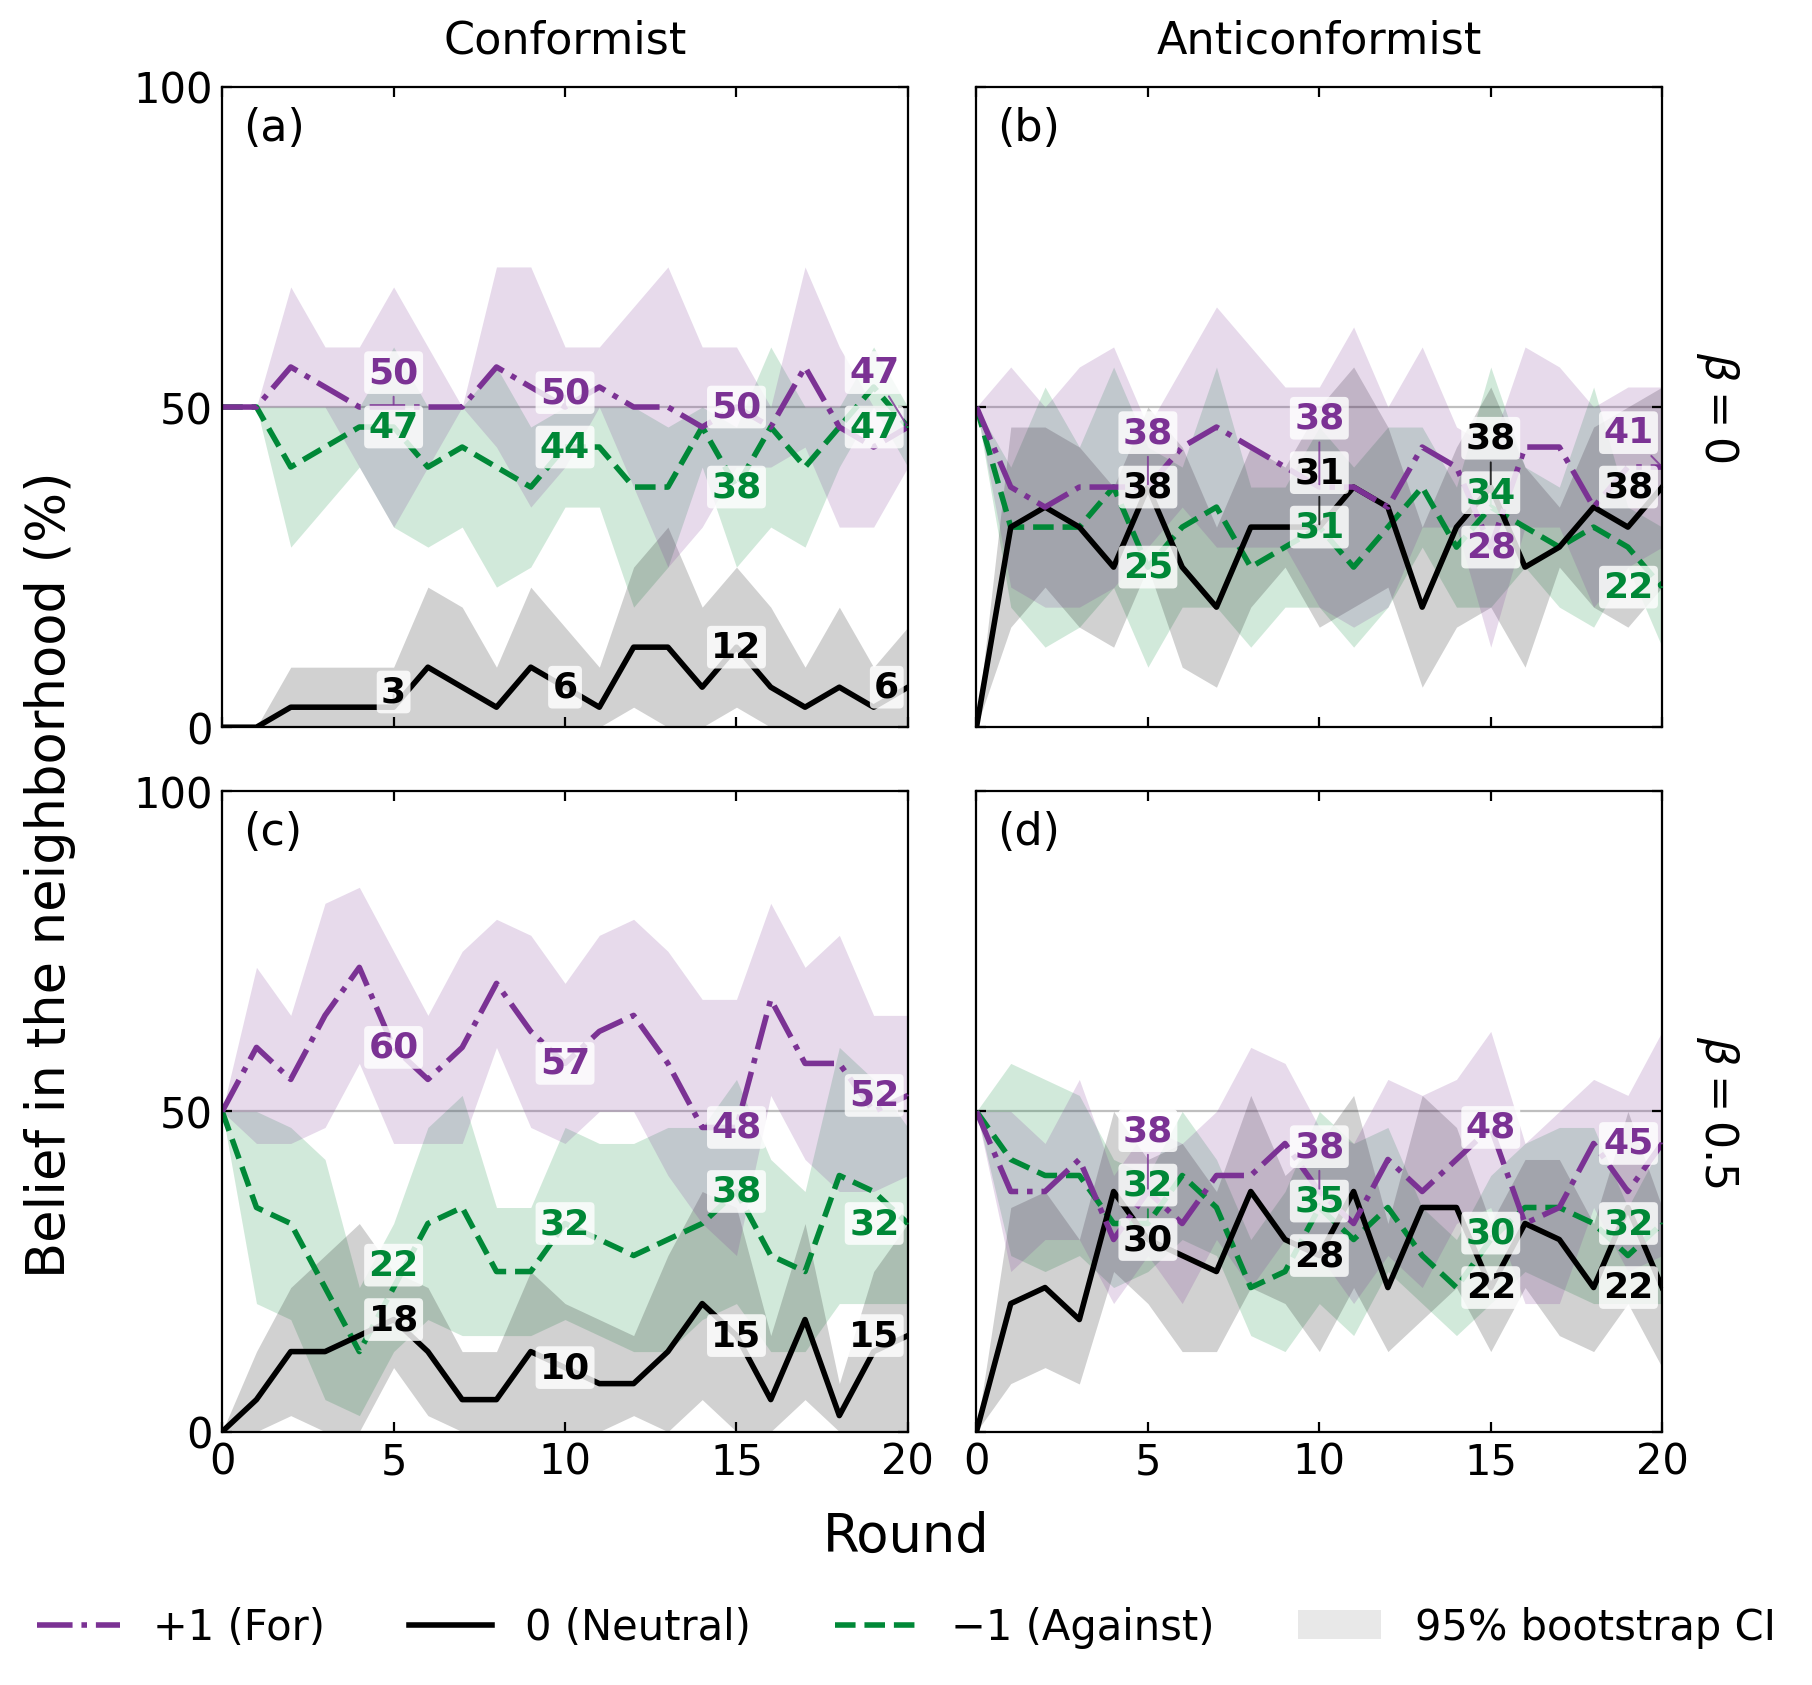

In [7]:
# Create the same trajectories with 95% bootstrap confidence bands.
from bootstrap import bootstrap
import numpy as np

np.random.seed(20260715)
bootstrap_annotation_rounds = [5, 10, 15, 20]

def make_nudge_bootstr_ci_summary(nid_table, group_columns):
    records = []
    for group_values, group in nid_table.groupby(group_columns, sort=True):
        if not isinstance(group_values, tuple):
            group_values = (group_values,)
        lower, upper = bootstrap(group['fraction'].to_numpy())
        records.append({
            **dict(zip(group_columns, group_values)),
            'mean_fraction': group['fraction'].mean(),
            'bootstr_ci_lower': lower,
            'bootstr_ci_upper': upper,
            'n_nid': group['nid'].nunique(),
        })
    return pd.DataFrame(records)

mean_fractions_bootstr_ci = make_nudge_bootstr_ci_summary(
    nid_fractions, ['beta', 'antic_nudge', 'round_no', 'response']
)
mean_fractions_framing_2_bootstr_ci = make_nudge_bootstr_ci_summary(
    nid_fractions_framing_2,
    ['beta', 'antic_nudge', 'round_no', 'response'],
)

def plot_nudge_trajectories_bootstr_ci(summary, x_data, output_name):
    fig, axes = plt.subplots(2, 2, figsize=(9, 8.2), sharex=True, sharey=True)

    for row, beta in enumerate(BETA_LEVELS):
        for col, antic_nudge in enumerate(ANTIC_NUDGE_LEVELS):
            ax = axes[row, col]
            panel = summary.loc[
                (summary['beta'] == beta)
                & (summary['antic_nudge'] == antic_nudge)
            ]
            trajectories = {}
            for response in RESPONSE_LEVELS:
                trajectory = panel.loc[
                    panel['response'] == response
                ].sort_values('round_no')
                trajectories[response] = trajectory
                ax.fill_between(
                    trajectory['round_no'],
                    trajectory['bootstr_ci_lower'],
                    trajectory['bootstr_ci_upper'],
                    color=colors[response], alpha=0.18, linewidth=0,
                )
                ax.plot(
                    trajectory['round_no'], trajectory['mean_fraction'],
                    color=colors[response], linewidth=2,
                    linestyle=line_styles[response],
                )

            for annotation_round in bootstrap_annotation_rounds:
                values = {
                    response: trajectories[response].loc[
                        trajectories[response]['round_no'] == annotation_round,
                        'mean_fraction',
                    ].iloc[0]
                    for response in RESPONSE_LEVELS
                }
                label_positions = spread_annotation_positions(values)
                text_x = (
                    annotation_round - 0.25
                    if annotation_round == bootstrap_annotation_rounds[-1]
                    else annotation_round
                )
                ha = (
                    'right'
                    if annotation_round == bootstrap_annotation_rounds[-1]
                    else 'center'
                )
                for response in RESPONSE_LEVELS:
                    ax.annotate(
                        f'{values[response] * 100:.0f}',
                        xy=(annotation_round, values[response]),
                        xytext=(text_x, label_positions[response]),
                        textcoords='data', color=colors[response],
                        fontsize=13, fontweight='bold', ha=ha, va='center',
                        clip_on=True, zorder=5,
                        bbox=dict(
                            boxstyle='round,pad=0.12', facecolor='white',
                            edgecolor='none', alpha=0.82,
                        ),
                        arrowprops=dict(
                            arrowstyle='-', color=colors[response],
                            linewidth=0.7, alpha=0.8, shrinkA=1, shrinkB=1,
                        ),
                    )

            if row == 0:
                nudge_label = (
                    'Conformist' if antic_nudge == 0 else 'Anticonformist'
                )
                ax.set_title(nudge_label, fontsize=16, pad=12)
            panel_label = chr(ord('a') + row * len(ANTIC_NUDGE_LEVELS) + col)
            ax.text(
                0.03, 0.97, f'({panel_label})', transform=ax.transAxes,
                ha='left', va='top', fontsize=16, fontweight='normal',
            )
            ax.set_xlim(x_data['round_no'].min(), x_data['round_no'].max())
            ax.set_ylim(0, 1)
            ax.set_yticks([0, 0.5, 1], ['0', '50', '100'])
            ax.set_xticks(
                range(
                    int(x_data['round_no'].min()),
                    int(x_data['round_no'].max()) + 1, 5,
                )
            )
            ax.grid(False)
            ax.axhline(0.5, color='0.75', linewidth=0.8, linestyle='-', zorder=0)
            ax.tick_params(
                axis='both', which='both', direction='in', top=True, right=True
            )
            for spine in ax.spines.values():
                spine.set_visible(True)
            if col == len(ANTIC_NUDGE_LEVELS) - 1:
                ax.text(
                    1.08, 0.5, rf'$\beta = {beta:g}$',
                    transform=ax.transAxes, rotation=270,
                    va='center', ha='center', fontsize=16,
                )

    legend_handles = [
        Line2D(
            [0], [0], color=colors[response], linewidth=2,
            linestyle=line_styles[response], label=labels[response],
        )
        for response in legend_order
    ]
    legend_handles.append(
        Patch(
            facecolor='0.5', alpha=0.18, edgecolor='none',
            label='95% bootstrap CI',
        )
    )
    fig.legend(
        handles=legend_handles, loc='lower center', ncol=4, frameon=False,
        bbox_to_anchor=(0.5, 0.005),
    )
    fig.supxlabel('Round', fontsize=19, y=0.08)
    fig.supylabel('Belief in the neighborhood (%)', fontsize=19, x=0.01)
    fig.subplots_adjust(
        left=0.12, right=0.92, bottom=0.16, top=0.98,
        wspace=0.10, hspace=0.10,
    )
    fig.savefig(output_name, dpi=300, bbox_inches='tight')
    plt.show()

plot_nudge_trajectories_bootstr_ci(
    mean_fractions_bootstr_ci, plot_data, 'Figure_3a_bootstr_ci.png'
)
plot_nudge_trajectories_bootstr_ci(
    mean_fractions_framing_2_bootstr_ci,
    plot_data_framing_2,
    'Figure_3b_bootstr_ci.png',
)